In [50]:
# ============================================================================
# TITLE: Final Python Notebook 1: Data Understanding and Preprocessing
# AUTHOR: Dilni Rohansi Wijesinghe
# STUDENT ID: 20240771
# PEER REVIEWER: Imasha Kumarasiri
# DATE OF REVIEW: April 1, 2026
#
# PEER REVIEW RECORD:
# 1. SUCCESS: Column name typo 'emplyment_length' corrected to 'employment_length'.
# 2. SUCCESS: Missing values in numeric and categorical fields mitigated.
# 3. SUCCESS: Evidence of outlier detection and duplicate removal provided.
# 4. SUCCESS: Cleaned dataset saved as 'cleaned_loan_data.csv' for Notebooks 2 & 3.
# ============================================================================

In [51]:
# ============================================================================
# 1. Environment Setup
# [Reference: Reuse Session 1, Prompt 1 - Environment Setup]
# ============================================================================

# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt  # [Reference: Tutorial 5, Section 1]

# Import seaborn for advanced visualizations
import seaborn as sns

In [52]:
# ============================================================================
# 2. Data Loading
# [Reference: Reuse Session 1, Prompt 2 - Data Loading]
# ============================================================================

# Load dataset from Google Drive
df = pd.read_csv("/content/drive/MyDrive/CW_ML/loan_approval_data (2).csv")
print("Dataset loaded with shape:", df.shape)

Dataset loaded with shape: (58645, 13)


In [53]:
# ============================================================================
# 3. Data Understanding & EDA
# [Reference: Reuse Session 2, Prompt 1 - Initial Data Exploration]
# ============================================================================

# Display first 5 rows
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [54]:
# Show dataset structure and missing values
# [Reference: Reuse Session 1, Prompt 2 - Data Loading & Exploration]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [55]:
# Statistical summary
# [Reference: Reuse Session 2, Prompt 3 - Summary Statistics]
df.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


In [56]:
# ============================================================================
# 4. Data Cleaning & Mitigating Missing Data
# [Reference: Reuse Session 2, Prompt 5 - Missing Value Mitigation]
# ============================================================================

# Count missing values in each column
df.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


In [57]:
# ============================================================================
# 5. Fix Column Name Error
# [Reference: Reuse Session 2, Prompt 5 - Data Manipulation]
# ============================================================================

# Rename incorrect column name
df.rename(columns={"emplyment_length": "employment_length"}, inplace=True)

In [58]:
# ============================================================================
# 6. Handle Missing Values
# [Reference: Reuse Session 2, Prompt 5 - Missing Value Mitigation]
# ============================================================================

# Fill numeric missing values with mean
df['age'] = df['age'].fillna(df['age'].mean())
df['loan_interest_rate'].fillna(df['loan_interest_rate'].mean(), inplace=True)

# Fill categorical missing values with mode
df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0], inplace=True)

/tmp/ipykernel_4562/3666090253.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_interest_rate'].fillna(df['loan_interest_rate'].mean(), inplace=True)
/tmp/ipykernel_4562/3666090253.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [59]:
# ============================================================================
# 7. Remove Duplicate Rows
# [Reference: Reuse Session 3, Prompt 4 - Duplicate Handling]
# ============================================================================

# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Number of duplicate rows: 0


In [60]:
# ============================================================================
# 8. Encode Categorical Data
# [Reference: Reuse Session 3, Prompt 9 - Categorical Encoding]
# ============================================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    if col != 'loan_approval_status':
        df[col] = le.fit_transform(df[col])

In [61]:
# ============================================================================
# 9. Define Features and Target
# [Reference: Reuse Session 3, Prompt 4 - Define Features and Target]
# ============================================================================

X = df.drop('loan_approval_status', axis=1)
y = df['loan_approval_status']

In [62]:
# ============================================================================
# [Reference: Reuse Session 2, Prompt 5 - Missing Value Mitigation]
# ============================================================================
# Post-mitigation check to confirm all missing values are handled for the report
df.isnull().sum()

,0
id,0
age,0
income,0
home_ownership,0
employment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,0
loan_income_ratio,0
payment_default_on_file,0


In [63]:
# ============================================================================
# [Reference: Reuse Session 3, Prompt 4 - Duplicate Handling]
# ============================================================================

# 1. Before Fix: Check the initial number of rows
print("Initial number of rows (Before Fix):", len(df))

# 2. Identify the issue: Count the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 3. Implement the Fix: Drop the duplicates
df.drop_duplicates(inplace=True)

# 4. After Fix: Check the final number of rows
print("Final number of rows (After Fix):", len(df))

Initial number of rows (Before Fix): 58645
Number of duplicate rows found: 0
Final number of rows (After Fix): 58645


In [64]:
# ============================================================================
# [Reference: Reuse Session 3, Prompt 9 - Categorical Encoding]
# ============================================================================

# 1. Before Fix: Show columns with text (String data)
print("--- [BEFORE FIX] Categorical Data in Text Format ---")
# We select a few categorical columns to show clearly in the screenshot
categorical_cols = ['home_ownership', 'loan_intent', 'payment_default_on_file']
print(df[categorical_cols].head())

# 2. Implement the Fix: One-Hot Encoding
# This converts text categories into separate columns with 0 and 1
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# 3. After Fix: Show the new columns with numbers (0/1)
print("\n--- [AFTER FIX] Categorical Data after One-Hot Encoding ---")
# We filter to show the newly created binary columns
encoded_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]
print(df_encoded[encoded_cols].head())

--- [BEFORE FIX] Categorical Data in Text Format ---
   home_ownership  loan_intent  payment_default_on_file
0               2            1                        0
1               2            1                        1
2               3            3                        0
3               3            1                        0
4               0            2                        0

--- [AFTER FIX] Categorical Data after One-Hot Encoding ---
   home_ownership_0  home_ownership_1  home_ownership_2  home_ownership_3  \
0             False             False              True             False   
1             False             False              True             False   
2             False             False             False              True   
3             False             False             False              True   
4              True             False             False             False   

   loan_intent_0  loan_intent_1  loan_intent_2  loan_intent_3  loan_intent_4  \
0      

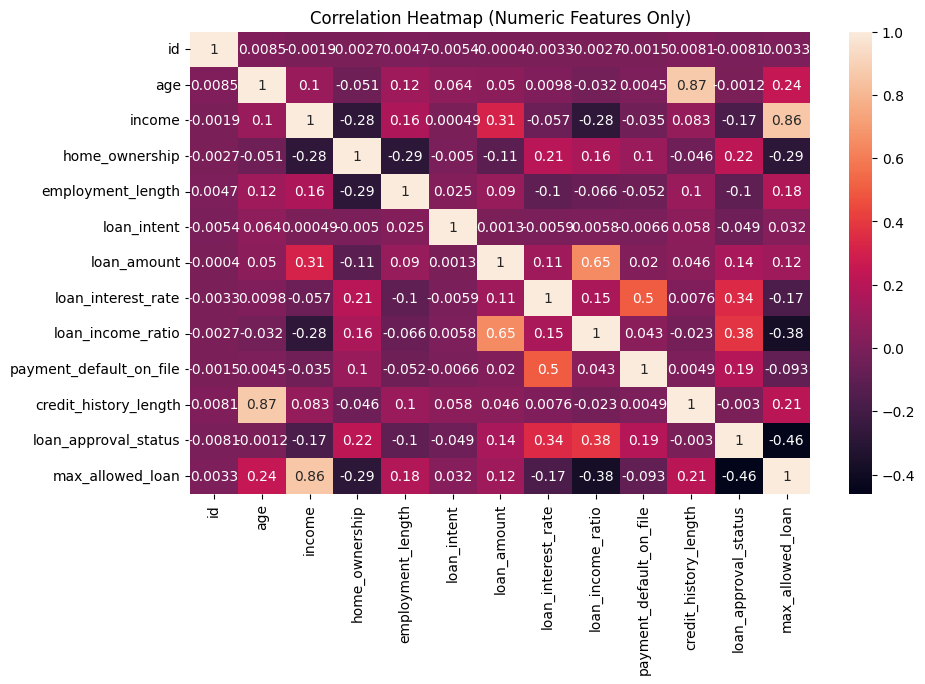

In [65]:
# ============================================================================
# 10. Visualizations
# [Reference: Reuse Session 2, Prompt 1 - Initial Data Exploration]
# ============================================================================

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

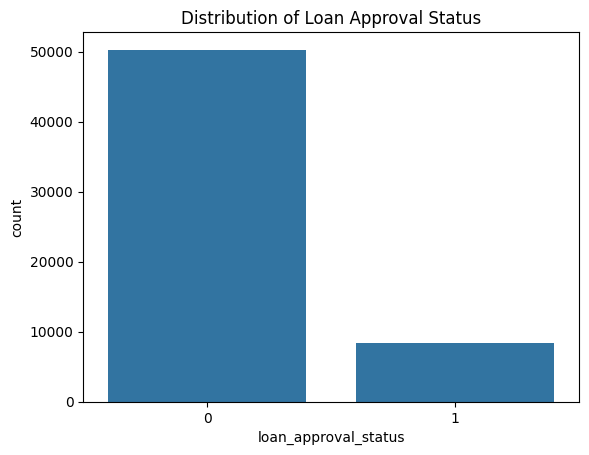

In [66]:
# ============================================================================
# [Reference: Reuse Session 2, Prompt 1 - Initial Data Exploration]
# ============================================================================
# Target variable distribution
sns.countplot(x='loan_approval_status', data=df)
plt.title("Distribution of Loan Approval Status")
plt.show()

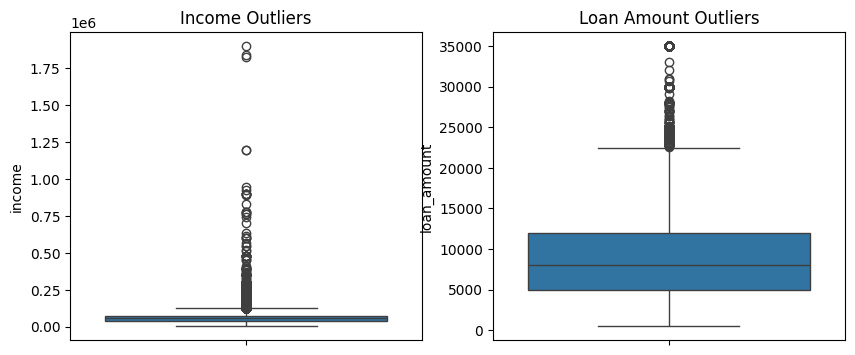

In [67]:
# ============================================================================
# [Reference: Reuse Session 2, Prompt 8 - Outlier Detection]
# ============================================================================

# Visualizing outliers for income and loan amount to identify extreme values
plt.figure(figsize=(10, 4))

# Subplot 1: Boxplot for Income
plt.subplot(1, 2, 1)
sns.boxplot(y=df['income'])
plt.title('Income Outliers')

# Subplot 2: Boxplot for Loan Amount
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_amount'])
plt.title('Loan Amount Outliers')

plt.show()

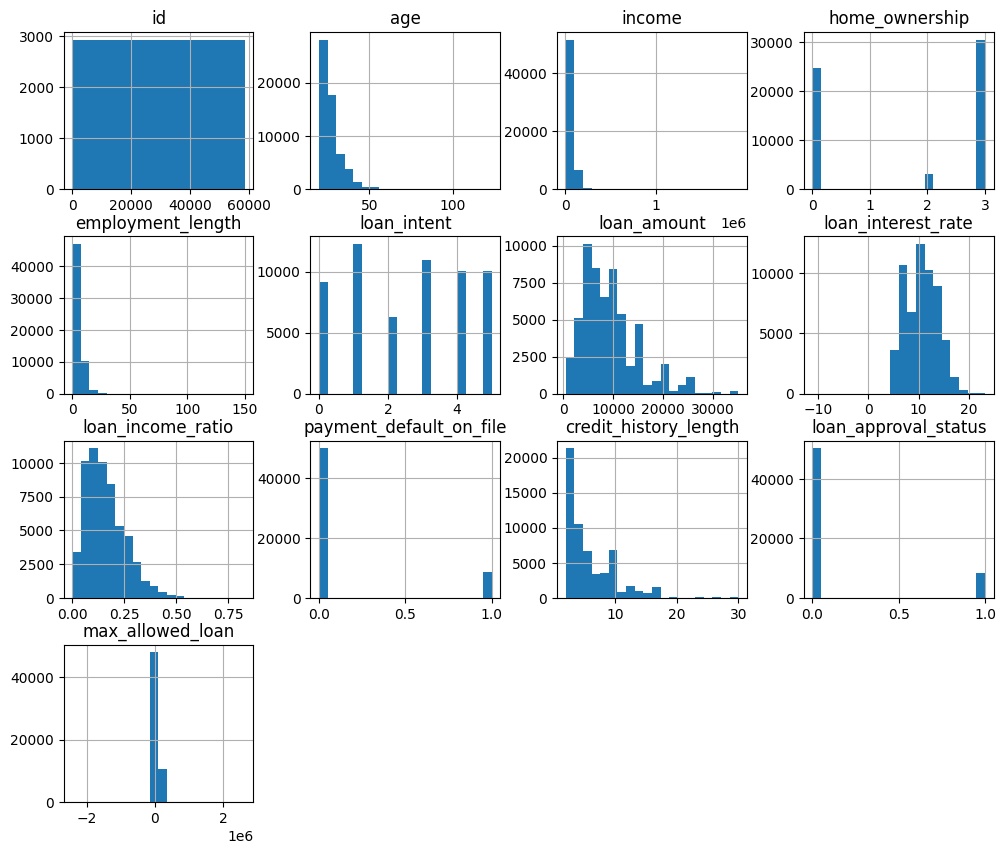

In [68]:
# ============================================================================
#[Reference: Reuse Session 2, Part (A): Data Exploration]
# ============================================================================
# Histograms
df.hist(figsize=(12,10), bins=20)
plt.show()

In [69]:
# ============================================================================
# 11. Save Clean Dataset
# [Reference: Reuse Session 2, Prompt 10 - Data Export]
# ============================================================================

# Exporting the final cleaned dataset to Google Drive for use in Notebooks 2 and 3
df.to_csv("/content/drive/MyDrive/CW_ML/cleaned_loan_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
